In [1]:
import cafe

img_dir = "img/26.01.28-metric_feature"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

数据导入与预处理

In [2]:
fadata = cafe.data.read_pancreas()
fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [3]:
import scvelo as scv

scv.pp.filter_and_normalize(fadata, min_counts=3, min_counts_u=3, n_top_genes=2000)

Filtered out 12228 genes that are detected 3 counts (spliced).
Filtered out 2960 genes that are detected 3 counts (unspliced).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


ref轨迹上的特征重要性排名

In [4]:
from cafe.metric.metric_featureimp import calculate_overall_feature_importance

featureimp_df = calculate_overall_feature_importance(fadata)
featureimp_df["gene"] = fadata.var_names[featureimp_df["feature_id"]]
featureimp_df

,feature_id,importance,gene
0,1849,0.008162,Hmgn3
1,1067,0.008030,Gnas
2,867,0.007749,Rbp4
3,1407,0.007252,Spp1
4,491,0.006897,Isl1
...,...,...,...
1995,536,0.000000,Gng2
1996,1275,0.000000,Zmym6
1997,1276,0.000000,Rnf19b
1998,1277,0.000000,Sync


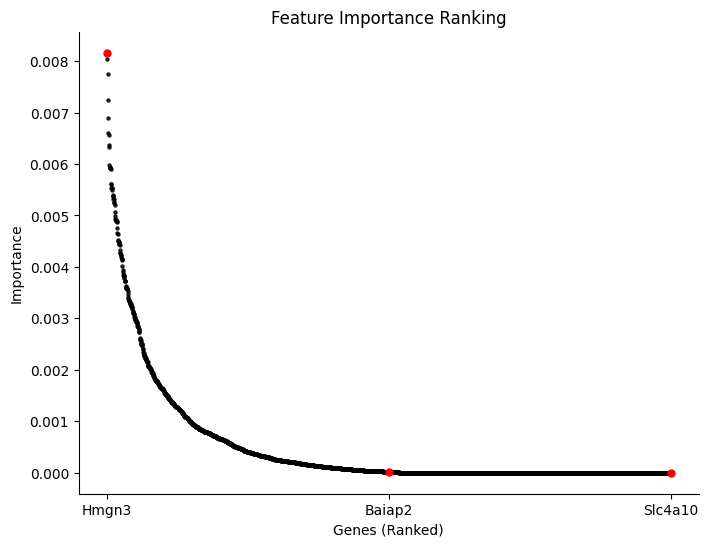

In [5]:
import matplotlib.pyplot as plt


# 设定绘制范围（例如前 500 个基因，避免X轴过长）
plot_top_n = 2000
df_plot = featureimp_df.head(plot_top_n).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))

# 1. 绘制主要曲线（用排名作为 X 轴）
ax.scatter(df_plot.index, df_plot["importance"], s=5, color="black", alpha=0.8)

# 2. 设定需要高亮/标记的基因
# 自动选择前 5 个，或者您可以手动指定列表，如 gene_list = ["Ins1", "Gcg"]
# gene_list = df_plot["gene"].head(5).tolist()
gene_list = df_plot["gene"][[0,plot_top_n//2, plot_top_n-1]].tolist()
# gene_list = ["Pdx1"]

marker_indices = []
marker_labels = []

for gene in gene_list:
    # 查找基因在排序后列表中的位置
    match = df_plot[df_plot["gene"] == gene]
    if not match.empty:
        idx = match.index[0]
        imp = match["importance"].values[0]
        
        marker_indices.append(idx)
        marker_labels.append(gene)
        
        # 用红点高亮
        ax.scatter([idx], [imp], s=25, color="red", zorder=10)

# 3. 自定义 X 轴刻度：只显示特定基因
ax.set_xticks(marker_indices)
ax.set_xticklabels(marker_labels, rotation=0, fontsize=10)

ax.set_xlabel("Genes (Ranked)")
ax.set_ylabel("Importance")
ax.set_title("Feature Importance Ranking")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(f"{img_dir}/feature_importance_ranking.pdf")
plt.show()

saving figure to file img/26.01.28-metric_feature/gene_expression_embedding.pdf


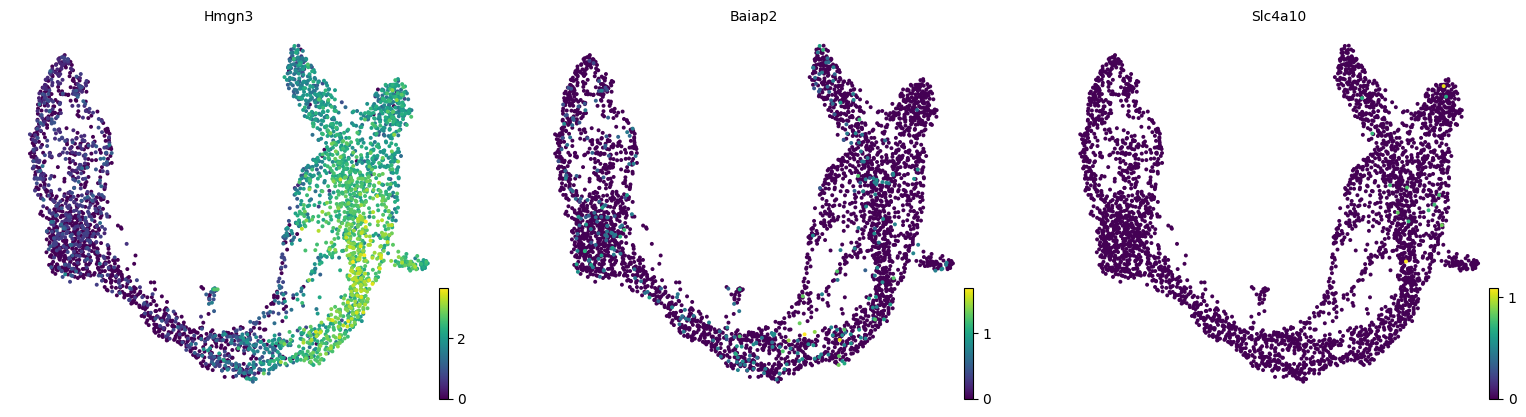

In [ ]:
scv.pl.umap(fadata, color=gene_list, save=f"{img_dir}/gene_expression_embedding.pdf")
cafe.plot.plot_graph(fadata, color=gene, save=f"{img_dir}/plot_graph_{gene}.pdf")

INFO     |- Preparing FateAnnData for stream plotting (model: ref)                                                                                                                                      


INFO     |- FateAnnData prepared successfully for stream plotting                                                                                                                                       
INFO     |- Plotting stream_sc with color: ['Hmgn3']                                                                                                                                                    
INFO     |- Saved stream plot to 'img/26.01.28-metric_feature/stream_plot_Hmgn3.pdf'                                                                                                                    


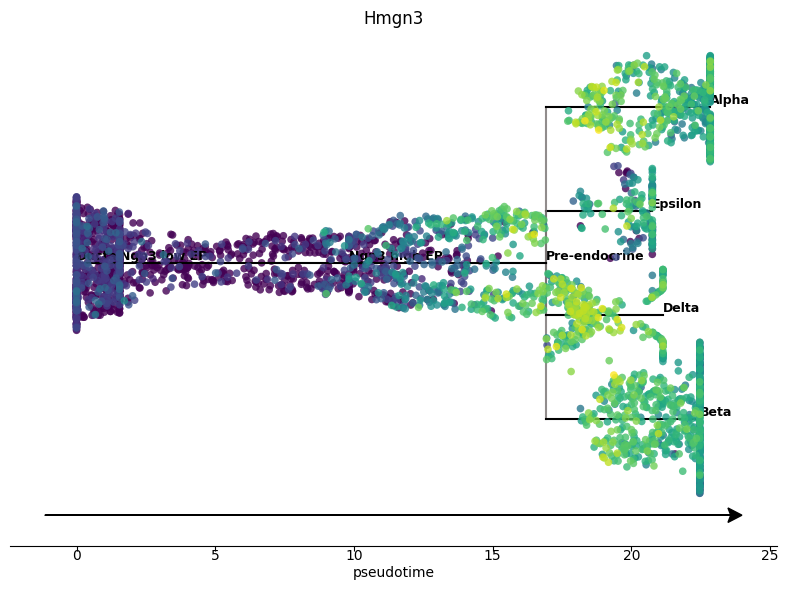

In [ ]:
gene = gene_list[0]
# plot
# figs = cafe.plot.plot_stream(
#     fadata, 
#     model_name="ref",
#     color=gene_list[0],
#     mode="cell",
#     fig_size=(8,6)
# )
figs = cafe.plot.plot_stream(
    fadata, 
    model_name="ref",
    color=gene,
    mode="cell",
    save=f"{img_dir}/stream_plot_{gene}.pdf",
    show_legend=False,
    fig_size=(8,6)
)

TODO: 提取前topn基因进行GO富集分析